# 14 — Learning from Pixels

A camera, a convolutional network, and the world it was not trained in ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/14-vision/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** This week renders
    thousands of camera pictures through EGL, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains three small networks on the CPU, about a minute each.

## The robot opens its eyes

For thirteen weeks the G1 has known only what is inside it: joint
angles, an IMU, and — in simulation — anything we chose to hand it. It
has never known **where anything else is**.

Today it gets a camera, and a network that turns pixels into a
direction.

1.  A camera is two lines of `MjSpec`; the labels come free from the
    simulator.
2.  A convolutional network learns *where the ball is* to about a
    degree.
3.  It fails — badly — on a ball of a different colour. We measure why.
4.  Randomising the training pictures fixes it, at a price.
5.  The network closes a loop: the robot turns to face the ball.

**Layer:** perception feeding Layer 5. The camera is a Layer 2 sensor;
what reads it is learned.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import math, time
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
import torch
from soc4180 import vision
from soc4180.render import _new_renderer

torch.manual_seed(0)
torch.set_num_threads(4)
model = vision.camera_model(("red",))
data = mujoco.MjData(model)
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
cam = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "head")
print(f"cameras {model.ncam}   mocap bodies {model.nmocap}   camera at height {data.cam_xpos[cam][2]:.2f} m")

cameras 1   mocap bodies 1   camera at height 1.28 m

`vision.camera_model` is the G1 scene plus **two additions** made with
`MjSpec` before compiling: a camera on `torso_link`, and one ball.

------------------------------------------------------------------------

## A camera is a body-fixed frame

``` python
spec = mujoco.MjSpec.from_file(str(soc4180.robot_path()))
spec.body("torso_link").add_camera(name="head", pos=[0.08, 0, 0.45],
                                   xyaxes=[0, -1, 0, 0, 0, 1], fovy=90)
ball = spec.worldbody.add_body(name="ball_red", mocap=True, pos=[1.2, 0, 0.8])
ball.add_geom(type=mujoco.mjtGeom.mjGEOM_SPHERE, size=[0.1, 0, 0],
              rgba=[0.9, 0.1, 0.1, 1], contype=0, conaffinity=0)
model = spec.compile()
```

- A camera is attached to a **body**, like a site: it moves with the
  torso, so when the waist turns, the picture turns.
- MuJoCo cameras look down their own **−z**. `xyaxes` names the camera’s
  x (image right) and y (image up) in the body frame: right = torso −y,
  up = +z, so it looks along +x — forward.
- A **mocap** body has no joint and feels no physics: you move it by
  writing `data.mocap_pos`. `contype = conaffinity = 0` means nothing
  can hit it. It is a target, not an object.

------------------------------------------------------------------------

## What the robot sees

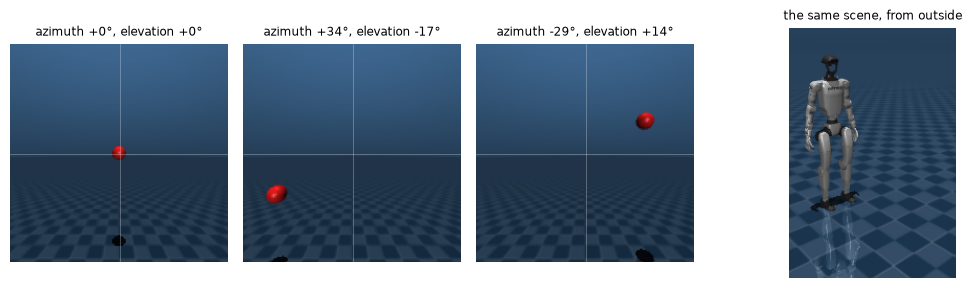

In [2]:
rng = np.random.default_rng(3)
shots = []
with _new_renderer(model, 160, 160) as r:
    for az, el in ((0.0, 0.0), (0.6, -0.3), (-0.5, 0.25)):
        vision.place_ball(model, data, 0, az, el, 1.6)
        mujoco.mj_forward(model, data)
        r.update_scene(data, camera="head"); shots.append((r.render().copy(), az, el))
with _new_renderer(model, 160, 240) as r:
    r.update_scene(data); outside = r.render().copy()
fig, axes = plt.subplots(1, 4, figsize=(11, 3.1), gridspec_kw=dict(width_ratios=[1, 1, 1, 1.5]))
for ax, (img, az, el) in zip(axes, shots):
    ax.imshow(img); ax.set_title(f"azimuth {math.degrees(az):+.0f}°, elevation {math.degrees(el):+.0f}°", fontsize=9)
    ax.axhline(80, color="w", lw=0.4, alpha=0.5); ax.axvline(80, color="w", lw=0.4, alpha=0.5); ax.axis("off")
axes[3].imshow(outside); axes[3].set_title("the same scene, from outside", fontsize=9); axes[3].axis("off")
fig.tight_layout(); plt.show()

Two angles say where the ball is: **azimuth** (positive to the robot’s
left) and **elevation** (positive up), measured from the middle of the
picture. A 90° field of view puts the edge of the picture at ±45°.

------------------------------------------------------------------------

## Labels for free

The whole difficulty of supervised learning on a real robot is *labels*:
someone has to say where the ball is in ten thousand photographs.

In simulation we **put** it there.

In [3]:
t0 = time.time()
X, Y = vision.render_dataset(model, 4000, seed=0)
Xtest, Ytest = vision.render_dataset(model, 500, seed=1000)
print(f"images {X.shape} {X.dtype}, labels {Y.shape}   ({time.time() - t0:.1f} s)")
print(f"first label: azimuth {math.degrees(Y[0, 0, 0]):+.1f}°, elevation {math.degrees(Y[0, 0, 1]):+.1f}°")

images (4000, 3, 64, 64) uint8, labels (4000, 1, 2)   (5.0 s)
first label: azimuth +11.0°, elevation -18.9°

Each picture is 64 × 64 × 3 = 12,288 numbers. Each label is 2. Rendering
the lot takes seconds; on a real robot the same dataset is a week of
work.

`render_dataset` places the ball at a random azimuth in ±40°, elevation
in −34°…+23° and distance 0.8–2.5 m, renders from `camera="head"`, and
records the two angles it chose.

------------------------------------------------------------------------

## 4000 of them, at the size the network sees

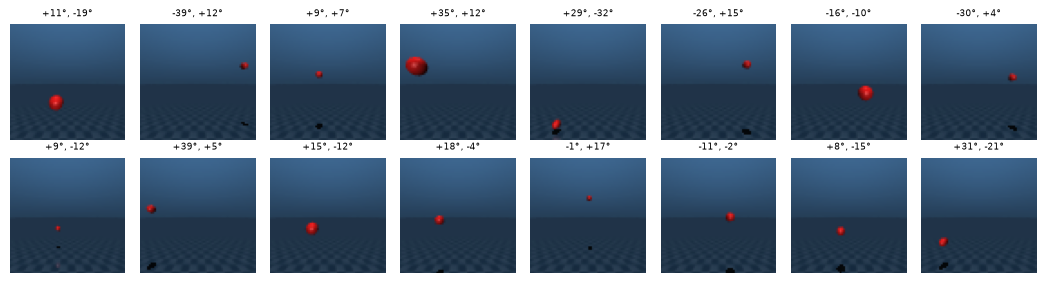

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, y in zip(axes.flat, X[:16], Y[:16]):
    ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
    ax.set_title(f"{math.degrees(y[0, 0]):+.0f}°, {math.degrees(y[0, 1]):+.0f}°", fontsize=7)
fig.tight_layout(); plt.show()

The ball is a few pixels across when it is far away. A network does not
need the picture to be pretty; it needs it to be *consistent*.

------------------------------------------------------------------------

## Why not an ordinary network?

A fully-connected layer from 12,288 pixels to 64 hidden units has
**786,000** weights, and each one is tied to *one pixel*. A ball seen at
the left edge and the same ball at the right edge share nothing: the
network would have to learn “red blob” separately at every position.

A **convolution** slides one small filter over every position of the
picture:

$$\text{out}[i,j] = \sum_{c}\sum_{u,v} w[c,u,v]\;\text{in}[c,\,i+u,\,j+v] + b$$

- The **same** 3×3×3 weights everywhere: *weight sharing*. A red-blob
  detector learned once works anywhere.
- Stride 2 halves the resolution each layer: 64 → 32 → 16 → 8. Deep
  cells see a wide patch of the picture.
- The output keeps the **layout**: cell $(i,j)$ is about that part of
  the image.

------------------------------------------------------------------------

## BallNet

In [5]:
def fresh(seed=0):
    torch.manual_seed(seed)          # the same starting weights every time, as look.py
    return vision.BallNet()

net = fresh()
print(net)
print(f"\nparameters: {sum(p.numel() for p in net.parameters()):,}")

BallNet(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=2, bias=True)
  )
)

parameters: 146,370

Three convolutions (16, 32, 32 channels, each stride 2), flatten the 32
× 8 × 8 result, then two linear layers down to **two numbers**. It
regresses the angles directly, with squared error — the same loss as
week 13’s behaviour cloning, pointed at a different question.

------------------------------------------------------------------------

## Training

In [6]:
def train(net, X, Y, epochs=10):
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    Xt, Yt = vision.as_tensor(X), torch.as_tensor(Y[:, 0])
    curve = []
    for epoch in range(epochs):
        perm = torch.randperm(len(Xt)); total = 0.0
        for i in range(0, len(Xt), 64):
            b = perm[i:i + 64]
            loss = ((net(Xt[b]) - Yt[b]) ** 2).mean()        # squared error, radians²
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * len(b)
        curve.append(math.degrees(math.sqrt(total / len(Xt))))
    return curve

def error_deg(net, images, labels):
    with torch.no_grad():
        p = net(vision.as_tensor(images)).numpy()
    return np.degrees(np.linalg.norm(p - labels[:, 0], axis=1))

t0 = time.time()
curve = train(net, X, Y)
err = error_deg(net, Xtest, Ytest)
guess = np.degrees(np.linalg.norm(Ytest[:, 0] - Y[:, 0].mean(0), axis=1)).mean()
print(f"{time.time() - t0:.0f} s; training error by epoch (deg rms): " + " ".join(f"{c:.1f}" for c in curve))
print(f"test: mean error {err.mean():.1f}°, {100 * np.mean(err < 5):.0f}% within 5°   "
      f"(always guessing the average: {guess:.1f}°)")

6 s; training error by epoch (deg rms): 16.2 7.7 3.9 2.4 1.8 1.5 1.7 1.8 1.2 1.1
test: mean error 1.0°, 100% within 5°   (always guessing the average: 26.0°)

About **one degree**, on pictures it never saw, from a network the size
of a thumbnail. That is the easy half of the week.

------------------------------------------------------------------------

## Where it is right, and where it is not

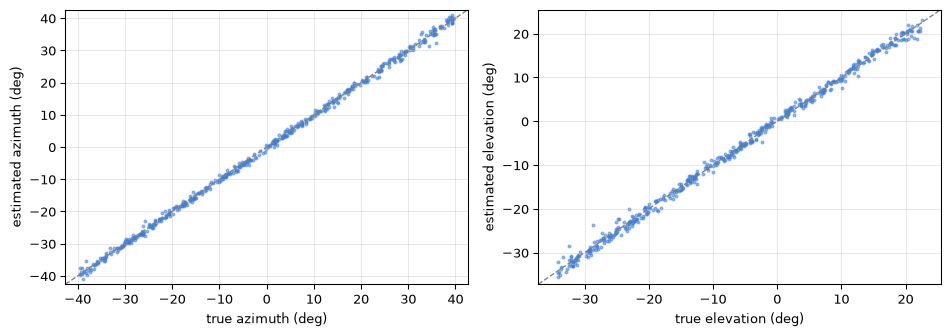

In [7]:
with torch.no_grad():
    pred = net(vision.as_tensor(Xtest)).numpy()
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, k, name in ((a0, 0, "azimuth"), (a1, 1, "elevation")):
    t, p = np.degrees(Ytest[:, 0, k]), np.degrees(pred[:, k])
    ax.scatter(t, p, s=4, alpha=0.5, color="#3b7dd8")
    lo, hi = t.min() - 3, t.max() + 3
    ax.plot([lo, hi], [lo, hi], color="0.5", lw=1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"true {name} (deg)"); ax.set_ylabel(f"estimated {name} (deg)"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Every point on the diagonal is a perfect estimate. Nobody told the
network what a ball is, or that red matters: it had to find *something*
in the pixels that predicts the two angles. The next slide asks whether
what it found was *ball*.

------------------------------------------------------------------------

## A different world

Same network, same camera, same scene. Two changes it was never shown: a
**blue** ball, and the lights at **30%**.

In [8]:
Xblue, Yblue = vision.render_dataset(model, 500, seed=1001, colour=lambda r: (0.1, 0.2, 0.9))
Xdim, Ydim = vision.render_dataset(model, 500, seed=1002, light=lambda r: 0.3)
rows = [("red ball (as trained)", Xtest, Ytest), ("blue ball", Xblue, Yblue), ("red ball, dim room", Xdim, Ydim)]
print(f"{'test set':22s} {'mean error':>11} {'within 5°':>10}")
for name, xi, yi in rows:
    e = error_deg(net, xi, yi)
    print(f"{name:22s} {e.mean():9.1f}°  {100 * np.mean(e < 5):8.0f}%")
print(f"{'always guess the mean':22s} {guess:9.1f}°")

test set                mean error  within 5°
red ball (as trained)        1.0°       100%
blue ball                   27.8°         2%
red ball, dim room          15.2°         1%
always guess the mean       26.0°

On the blue ball it is **worse than guessing the average**; in the dim
room fifteen times worse than on the pictures it knows. Whatever it
found in the pixels, it was not *ball*: it was closer to *red, lit like
this*.

------------------------------------------------------------------------

## What it sees, what it says

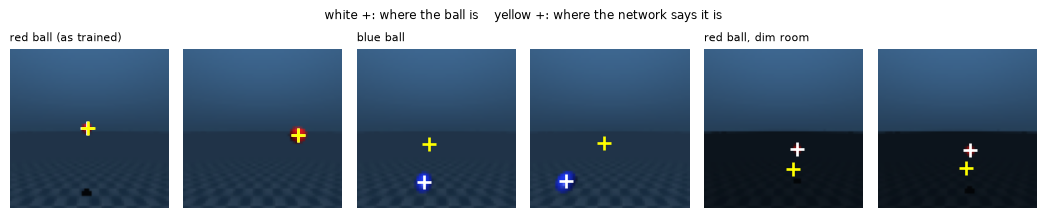

In [9]:
fig, axes = plt.subplots(1, 6, figsize=(11, 2.3))
for col, (name, xi, yi) in enumerate(rows):
    for k in range(2):
        ax = axes[2 * col + k]; img = xi[k]
        with torch.no_grad():
            p = net(vision.as_tensor(img[None])).numpy()[0]
        ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
        for (a, e), c in ((yi[k, 0], "w"), (p, "yellow")):
            u, v = vision.uv_of(a, e)
            ax.plot((u + 1) * 32 - 0.5, (v + 1) * 32 - 0.5, "+", color=c, ms=10, mew=2)
        ax.set_title(name if k == 0 else "", fontsize=8, loc="left")
fig.suptitle("white +: where the ball is    yellow +: where the network says it is", fontsize=9)
fig.tight_layout(); plt.show()

On the pictures it knows, the two crosses coincide. On the others the
yellow cross wanders: the network is not *uncertain*, it is
**confidently wrong**. Nothing in its output says “I have never seen
this before”.

------------------------------------------------------------------------

## This is the sim-to-real gap for eyes

A camera network trained in simulation meets a real camera and sees:
other colours, other lights, textures, lens blur, noise, motion blur, a
cable in the way. Every one of those is a “blue ball”.

**Domain randomisation** — Tobin et al., 2017 — is the week-12 idea
again: if you cannot make the simulator match the world, make the
simulator **vary so much** that the world looks like one more sample.

In [10]:
t0 = time.time()
Xr, Yr = vision.render_dataset(model, 4000, seed=0,
                               colour=lambda r: r.uniform(0, 1, 3),     # any colour at all
                               light=lambda r: r.uniform(0.3, 1.0))     # any brightness from 30% up
net_r = fresh(); curve_r = train(net_r, Xr, Yr)
print(f"trained on randomised pictures in {time.time() - t0:.0f} s")
print(f"{'test set':22s} {'plain':>8} {'randomised':>11}")
for name, xi, yi in rows:
    print(f"{name:22s} {error_deg(net, xi, yi).mean():7.1f}°  {error_deg(net_r, xi, yi).mean():9.1f}°")

trained on randomised pictures in 10 s
test set                  plain  randomised
red ball (as trained)      1.0°        4.4°
blue ball                 27.8°        9.4°
red ball, dim room        15.2°        4.2°

------------------------------------------------------------------------

## The price, and what it bought

| trained on                       | red, as trained | blue ball | dim room |
|----------------------------------|-----------------|-----------|----------|
| red balls only                   | **1.0°**        | 27.8°     | 15.2°    |
| random colour                    | 4.1°            | **5.0°**  | 27.2°    |
| random light                     | 1.3°            | 28.7°     | **1.6°** |
| both                             | 4.4°            | 9.4°      | 4.2°     |
| both, 12,000 pictures, 20 epochs | 4.4°            | 6.0°      | 3.8°     |

Measured with `look.py --randomise` (4000 pictures, 10 epochs unless
stated). Three lessons, each visible in one column:

1.  **Randomisation fixes exactly what it randomises.** Random light
    cures the dim room and does nothing for the blue ball; random colour
    the reverse.
2.  **Robustness costs accuracy on the easy case** — 1.0° becomes 4.4°.
    The network now has to be right about more worlds with the same
    capacity.
3.  **More data buys back the hard cases, not the easy one.** Three
    times the pictures and twice the epochs: blue 9.4° → 6.0°, dim 4.2°
    → 3.8°, red still 4.4°.

------------------------------------------------------------------------

## Closing the loop

A direction is only useful if something acts on it. The simplest action:
turn the waist until the ball is in the middle of the picture.

$$\text{waist}_{k+1} = \text{waist}_k + g\;\hat{a}_k$$

where $\hat a_k$ is the network’s azimuth from the picture taken at step
$k$, ten times a second. This is **visual servoing**: the error is
measured in the image, and the camera moves with the thing being
controlled.

In [11]:
def servo(net, gain, az0=35.0, seconds=3.0):
    d = mujoco.MjData(model); mujoco.mj_resetDataKeyframe(model, d, 0); mujoco.mj_forward(model, d)
    vision.place_ball(model, d, 0, math.radians(az0), 0.0, 1.5); ball = d.mocap_pos[0].copy(); mujoco.mj_forward(model, d)
    act_q = [int(model.jnt_qposadr[model.actuator_trnid[a, 0]]) for a in range(model.nu)]
    wq = soc4180.joint_index(model, "waist_yaw"); act = act_q.index(wq)
    d.ctrl[:] = model.key_qpos[0][act_q]
    log = []
    with _new_renderer(model, 64, 64) as r:
        while d.time < seconds:
            r.update_scene(d, camera="head")
            with torch.no_grad():
                est = float(net(vision.as_tensor(r.render().transpose(2, 0, 1)[None]))[0, 0])
            d.ctrl[act] = float(np.clip(d.ctrl[act] + gain * est, *model.actuator_ctrlrange[act]))
            log.append((d.time, math.degrees(d.qpos[wq]), math.degrees(vision.ball_direction(model, d, 0)[0]), d.qpos[2]))
            for _ in range(50):
                d.mocap_pos[0] = ball; mujoco.mj_step(model, d)
    return np.array(log)

runs = {g: servo(net, g) for g in (0.3, 0.8, 1.5, 2.2)}
for g, log in runs.items():
    print(f"gain {g:3.1f}: final ball offset {log[-1, 2]:+6.1f}°, pelvis {log[-1, 3]:.2f} m"
          + ("   FELL" if log[:, 3].min() < 0.5 else ""))

gain 0.3: final ball offset   +1.0°, pelvis 0.79 m
gain 0.8: final ball offset   +1.1°, pelvis 0.79 m
gain 1.5: final ball offset   +0.7°, pelvis 0.79 m
gain 2.2: final ball offset  +62.4°, pelvis 0.13 m   FELL

------------------------------------------------------------------------

## Four gains, drawn

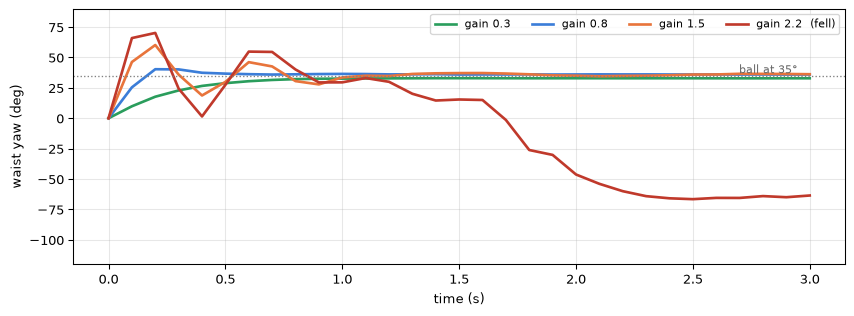

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for (g, log), c in zip(runs.items(), ("#2a9d5c", "#3b7dd8", "#e8743b", "#c0392b")):
    ax.plot(log[:, 0], log[:, 1], color=c, lw=2, label=f"gain {g}" + ("  (fell)" if log[:, 3].min() < 0.5 else ""))
ax.axhline(35, color="0.5", ls=":", lw=1); ax.text(2.95, 37, "ball at 35°", ha="right", fontsize=8, color="0.4")
ax.set_ylim(-120, 90); ax.set_xlabel("time (s)"); ax.set_ylabel("waist yaw (deg)"); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=4)
fig.tight_layout(); plt.show()

Week 5 in a new costume. Low gain is slow; 0.8 overshoots a little; 1.5
oscillates and settles; at 2.2 the torso swings so hard that **the robot
falls**, and once the ball leaves the picture the network’s output is
meaningless — it was never shown a picture with no ball in it.

------------------------------------------------------------------------

## What real robots do differently

| here | on a real robot |
|------------------------------------|------------------------------------|
| 64 × 64 pixels, rendered | 640 × 480 or more, from a lens, with noise and blur |
| one red ball | everything — people, doors, cups, cables |
| 4000 pictures, labelled free | pretrained encoders (ResNet, DINOv2, CLIP) trained on millions of images, then a small head trained on the robot’s own data |
| one frame, no memory | stacks of frames, or a recurrent state: motion is information |
| 10 Hz, no latency | 30–60 Hz, 30–100 ms from photon to action |
| colour randomisation | randomised textures, lights, camera poses, distractors, *and* real images |

The shape is the same: pixels → a small number of task-relevant
quantities → a controller. What changes is the size of the first arrow,
and that is why week 15 borrows an encoder instead of training one.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/14-vision/lab_look.py         # torch: uv sync --extra rl
```

A game, like weeks 3 and 11. **You edit only `eyes.py`**: a training
*recipe* per problem — how many pictures, how many epochs, what varies
(the ball’s colour, the room’s light) — and the waist gain. `1`–`5`
train and test (the window freezes while training, 15–20 s), with the
head camera’s view in the corner: white + the truth, yellow + the
network. `G` grades all five; `eyes.py` ships with its key numbers as
`...` and scores 0 / 5.

| \# | Problem | Measured with the reference recipe |
|------------------------|------------------------|------------------------|
| 1 | RED: under 2° | 1.0° (red balls only) |
| 2 | BLUE: under 8° | 5.0° (random colours); red-only scores 27.8° |
| 3 | DIM: under 3° | 1.6° (light 30–100 %); red-only scores 15.2° |
| 4 | ALL three, one network | 4.4° / 9.4° / 4.2° |
| 5 | TURN: within 3° by 0.6 s, never past 45° | gain 0.5–0.8 pass; 0.3 is slow, 1.2 overshoots, 2.2 falls |

------------------------------------------------------------------------

## Lab class: `look.py`

``` bash
uv run weeks/14-vision/look.py
uv run weeks/14-vision/look.py --randomise both
uv run weeks/14-vision/look.py --gain 2.2 --no-viewer
```

Renders, trains, tests on three worlds, closes the loop, replays.

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | camera + ball | `MjSpec.from_file`, `body.add_camera`, `worldbody.add_body(mocap=True)`, `compile` |
| 2 | data | `data.mocap_pos`, `Renderer.update_scene(data, camera="head")`, `render` |
| 3 | train | `BallNet`, `torch.optim.Adam` |
| 4 | test | `render_dataset(colour=, light=)`, `model.geom_rgba`, `model.light_diffuse` |
| 5 | close the loop | `data.ctrl[waist]`, `mj_step`, `vision.ball_direction` |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Resolution.** Train at 32 × 32 and at 96 × 96 (`--res`). How does
    the error change with distance to the ball?
2.  **Fewer pictures.** Train on 250, 500, 1000, 4000. Plot test error
    against dataset size. Where does it stop improving?
3.  **A second ball.** Put a blue ball in every training picture as a
    distractor. What does the network learn to report, and how would you
    tell it which ball you mean? (That is week 15.)
4.  **Say “I don’t know”.** Add a third output, *ball visible*, trained
    on pictures with and without the ball. Use it to stop the servo from
    chasing garbage.
5.  **Gain against latency.** Render the picture one decision late. What
    is the largest gain that still settles?
6.  **Honest randomisation.** Randomise the floor colour too. Which test
    world gets worse, and why?

------------------------------------------------------------------------

## Next week

**15 — Language.** Four balls, one sentence: *“look at the green one.”*
A network has to find a **word** in the picture — the same attention a
transformer computes, with one query — and then an agent has to turn
instructions into a sequence of skills and check that each one worked.